# Capítulo 7 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 7. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

sigma_w, rho_L, Rv, T0 = 0.0761, 1000.0, 461.0, 283.15
A_K = 2*sigma_w/(rho_L*Rv*T0)

## T1 — Equação de Kelvin por energia livre

**Solução.** Formar uma gota de raio $r$ custa energia de superfície $4\pi r^2\sigma$ e libera energia de volume $\frac43\pi r^3\,\Delta\mu/v_m$, com $\Delta\mu = k_BT\ln(e/e_s)$ por molécula (razão de saturação). Em equilíbrio instável $\partial G/\partial r = 0$:
$$k_BT\ln\frac{e}{e_s} = \frac{2\sigma v_m}{r} \;\Rightarrow\; \frac{e_s(r)}{e_s(\infty)} = \exp\!\left(\frac{2\sigma}{\rho_L \Re_v T\,r}\right).\;∎$$

In [2]:
for r_um in [0.01, 0.1, 1.0]:
    UR = 100*np.exp(A_K/(r_um*1e-6))
    print(f'r = {r_um:5.2f} µm → UR de equilíbrio = {UR:6.1f}%')
print('\n0,01 µm exige 112% — inalcançável: por isso a nucleação homogênea não ocorre.')

r =  0.01 µm → UR de equilíbrio =  112.4%
r =  0.10 µm → UR de equilíbrio =  101.2%
r =  1.00 µm → UR de equilíbrio =  100.1%

0,01 µm exige 112% — inalcançável: por isso a nucleação homogênea não ocorre.


## T2 — Extremos da curva de Köhler

In [3]:
r_, A_, B_, rd_ = sp.symbols('r A B r_d', positive=True)
S = 1 + A_/r_ - B_*rd_**3/r_**3
rstar = sp.solve(sp.diff(S, r_), r_)[0]
Sstar = sp.simplify(S.subs(r_, rstar))
display(sp.Eq(sp.Symbol('r^*'), rstar))
display(sp.Eq(sp.Symbol('S^*'), Sstar))
print('r* ∝ r_d^{3/2}: núcleo maior → portão mais largo;')
print('S*−1 ∝ r_d^{-3/2}: núcleo maior → ativa com supersaturação menor. ✓')

Eq(r^*, sqrt(3)*sqrt(B)*r_d**(3/2)/sqrt(A))

Eq(S^*, 2*sqrt(3)*A**(3/2)/(9*sqrt(B)*r_d**(3/2)) + 1)

r* ∝ r_d^{3/2}: núcleo maior → portão mais largo;
S*−1 ∝ r_d^{-3/2}: núcleo maior → ativa com supersaturação menor. ✓


## T3 — Tempos de crescimento por difusão

**Solução.** $r\,dr = C\,dt \Rightarrow t = (r_2^2 - r_1^2)/2C$. O tempo depende do **quadrado** dos raios — daí o gargalo:

In [4]:
C = 8.5e-14   # m²/s (S−1 ≈ 0,5%)
t1 = ((10e-6)**2 - (1e-6)**2)/(2*C)
t2 = ((1e-3)**2 - (10e-6)**2)/(2*C)
print(f'1 → 10 µm : {t1/60:8.1f} min  (constrói a nuvem)')
print(f'10 µm → 1 mm: {t2/86400:6.1f} DIAS (não constrói a chuva)')

1 → 10 µm :      9.7 min  (constrói a nuvem)
10 µm → 1 mm:   68.1 DIAS (não constrói a chuva)


## T4 — Velocidade de Stokes

**Solução.** Peso − empuxo $= \frac43\pi r^3 g(\rho_L - \rho)$; arrasto viscoso $= 6\pi\mu r w$. Igualando:
$$w_T = \frac{2}{9}\,\frac{g\,(\rho_L-\rho)}{\mu}\,r^2 \equiv k_1 r^2.$$

In [5]:
mu = 1.8e-5
k1 = 2*9.8*(rho_L - 1.2)/(9*mu)
print(f'k1 = {k1:.2e} m⁻¹s⁻¹  (livro: 1,19e8) ✓')
for r_um in [5, 10, 40]:
    print(f'  r = {r_um:3d} µm → wT = {k1*(r_um*1e-6)**2*100:6.2f} cm/s')

k1 = 1.21e+08 m⁻¹s⁻¹  (livro: 1,19e8) ✓
  r =   5 µm → wT =   0.30 cm/s
  r =  10 µm → wT =   1.21 cm/s
  r =  40 µm → wT =  19.33 cm/s


## T5 — Momentos de Marshall–Palmer

In [6]:
D_, lam_, N0_ = sp.symbols('D Lambda N_0', positive=True)
M3 = sp.integrate(N0_*sp.exp(-lam_*D_)*D_**3, (D_, 0, sp.oo))
display(sp.Eq(sp.Symbol('M_3'), M3))
print('→ M = (πρ_L/6)·N0·Γ(4)/Λ⁴ = πρ_L·N0/Λ⁴  (Γ(4)=6) ✓')
# diâmetro mediano por massa: metade da massa abaixo de D_m → Γ incompleta
# aproximação clássica: D_m ≈ 3,67/Λ (mediana) ou D médio ponderado por massa 4/Λ
Dm = sp.integrate(N0_*sp.exp(-lam_*D_)*D_**4, (D_, 0, sp.oo))/M3
display(sp.Eq(sp.Symbol('D_m'), sp.simplify(Dm)))
print('→ diâmetro médio ponderado por massa = 4/Λ ✓')

Eq(M_3, 6*N_0/Lambda**4)

→ M = (πρ_L/6)·N0·Γ(4)/Λ⁴ = πρ_L·N0/Λ⁴  (Γ(4)=6) ✓


Eq(D_m, 4/Lambda)

→ diâmetro médio ponderado por massa = 4/Λ ✓


---
## N1 — $S^*(r_d, \kappa)$

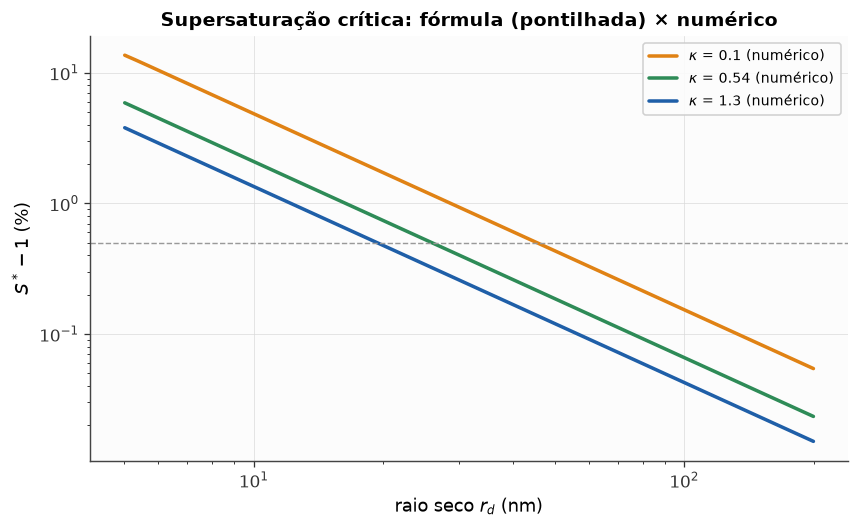

Com S ~ 0,5% típico, ativam núcleos com rd ≳ 40–100 nm conforme κ.


In [7]:
rd = np.logspace(-8.3, -6.7, 60)          # 5 a 200 nm
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for kap, cor in [(0.1, CORES['laranja']), (0.54, CORES['verde']),
                  (1.3, CORES['azul'])]:
    # numérico: máximo da curva
    Sstar_num = []
    for rdi in rd:
        r = np.logspace(np.log10(rdi*1.2), -5, 4000)
        Sstar_num.append((1 + A_K/r - kap*rdi**3/r**3).max())
    Sstar_teo = 1 + np.sqrt(4*A_K**3/(27*kap*rd**3))
    ax.loglog(rd*1e9, 100*(np.array(Sstar_num)-1), color=cor,
              label=f'$\\kappa$ = {kap} (numérico)')
    ax.loglog(rd*1e9, 100*(Sstar_teo-1), ':', color=cor, lw=1.2)
ax.axhline(0.5, color='#999999', ls='--', lw=0.9)
ax.set(xlabel='raio seco $r_d$ (nm)', ylabel='$S^*-1$ (%)',
       title='Supersaturação crítica: fórmula (pontilhada) × numérico')
ax.legend(fontsize=9)
plt.show()
print('Com S ~ 0,5% típico, ativam núcleos com rd ≳ 40–100 nm conforme κ.')

## N2 — Ar limpo × poluído no `pyrcel`

In [8]:
import pyrcel as pm

for nome, Ntot in [('limpo   ', 850.0), ('poluído ', 1700.0)]:
    aer = pm.AerosolSpecies('sulfato', pm.Lognorm(mu=0.05, sigma=2.0, N=Ntot),
                            kappa=0.54, bins=120)
    model = pm.ParcelModel([aer], 1.0, T0, -0.02, 85000.0)
    out = model.run(t_end=600.0, output_dt=1.0)
    s = out.summary
    print(f'{nome}: N = {Ntot:5.0f}/cm³ | S_max = {100*s["S_max"]:.3f}% | '
          f'ativadas = {100*s["total_act_frac"]:.0f}% '
          f'= {s["total_act_frac"]*Ntot:.0f} gotas/cm³')
print('\nDobrar o aerossol NÃO dobra as gotas (competição por vapor reduz S_max),')
print('mas o número absoluto sobe — gotas mais numerosas e menores: nuvem mais')
print('brilhante e chuva mais difícil (efeitos indiretos do aerossol, Cap. 21).')

limpo   : N =   850/cm³ | S_max = 0.286% | ativadas = 67% = 567 gotas/cm³


poluído : N =  1700/cm³ | S_max = 0.219% | ativadas = 59% = 996 gotas/cm³

Dobrar o aerossol NÃO dobra as gotas (competição por vapor reduz S_max),
mas o número absoluto sobe — gotas mais numerosas e menores: nuvem mais
brilhante e chuva mais difícil (efeitos indiretos do aerossol, Cap. 21).


## N3 — Raio de crossover difusão → coleta

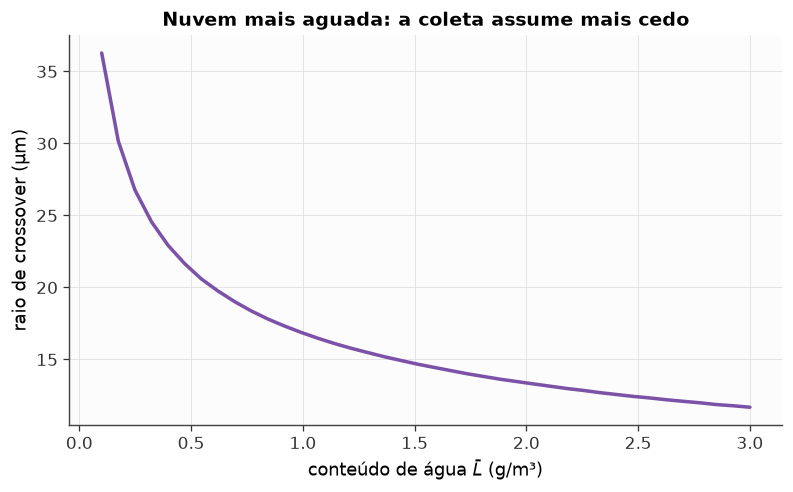

L = 0,3 g/m³ → crossover em 25 µm; L = 3 g/m³ → 12 µm


In [9]:
C_dif, k1, E_col = 8.5e-14, 1.19e8, 0.6
wT = lambda r: np.minimum(k1*r**2, 9.0)

Ls = np.linspace(0.1, 3.0, 40)
r_cross = []
r_grid = np.logspace(-6, -3, 4000)
for L in Ls:
    taxa_dif = C_dif/r_grid
    taxa_col = E_col*(L*1e-3)*wT(r_grid)/(4*rho_L)
    r_cross.append(r_grid[np.argmax(taxa_col > taxa_dif)]*1e6)

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(Ls, r_cross, color=CORES['roxo'])
ax.set(xlabel='conteúdo de água $\\bar L$ (g/m³)',
       ylabel='raio de crossover (µm)',
       title='Nuvem mais aguada: a coleta assume mais cedo')
plt.show()
print(f'L = 0,3 g/m³ → crossover em {np.interp(0.3, Ls, r_cross):.0f} µm; '
      f'L = 3 g/m³ → {np.interp(3.0, Ls, r_cross):.0f} µm')

## N4 — $D_m$ e a dominância das gotas grandes no radar

In [10]:
N0 = 8.0e3
D = np.linspace(0.01, 10, 4000)
for R in [1.0, 10.0, 50.0]:
    lam = 4.1*R**(-0.21)
    N = N0*np.exp(-lam*D)
    m = D**3*N
    Dm_num = np.trapezoid(D*m, D)/np.trapezoid(m, D)
    Z_tot = np.trapezoid(N*D**6, D)
    frac_Z = np.trapezoid((N*D**6)[D > Dm_num], D[D > Dm_num])/Z_tot
    print(f'R = {R:4.0f} mm/h: D_m numérico = {Dm_num:.2f} mm | 4/Λ = {4/lam:.2f} mm'
          f' | fração de Z acima de D_m: {100*frac_Z:.0f}%')
print('\nO D⁶ faz o radar enxergar quase só a cauda de gotas grandes.')

R =    1 mm/h: D_m numérico = 0.98 mm | 4/Λ = 0.98 mm | fração de Z acima de D_m: 89%
R =   10 mm/h: D_m numérico = 1.58 mm | 4/Λ = 1.58 mm | fração de Z acima de D_m: 89%
R =   50 mm/h: D_m numérico = 2.22 mm | 4/Λ = 2.22 mm | fração de Z acima de D_m: 89%

O D⁶ faz o radar enxergar quase só a cauda de gotas grandes.


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*